 # Landsat8 Data - June-Sept 2025
This produces 6 different band sets, so it takes awhile to produce

From 04_demo_download

Data_source: https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2 

In [18]:
import pystac
from pystac_client import Client
import planetary_computer
import odc.stac
import matplotlib.pyplot as plt
import os
from pathlib import Path
import urllib

import geopandas as gpd
import rasterio as rio
import rioxarray as rxr
from matplotlib_scalebar.scalebar import ScaleBar
import pyproj
import numpy as np

In [3]:
imgdir = f'{Path.home()}/snONP/snONP_Data/LS8_data_8_18_15'

if not os.path.exists(imgdir):
    os.makedirs(imgdir)

In [8]:
#Collection and bands (specific bands for L2 surface reflectance/temperature products)
collection = 'landsat-c2-l2'
asset_id_list = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'ST_B10', 'reduced_resolution_browse']
asset_id_list = ['coastal', 'blue', 'green', 'red', 'nir08', 'swir16', 'lwir11', 'rendered_preview']

#Bounding box
bbox = [-124.6,47.47,-122.9,48.1]



#Date range
dt = '2025-06-01/2025-09-30'   #Before the start of the water year

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1",modifier=planetary_computer.sign_inplace)

results = catalog.search(
    collections=[collection],
    bbox=bbox,
    datetime=dt,
    query={
        "eo:cloud_cover": {"lt": 50},  # Less than 50% cloud cover
        "landsat:wrs_path": {"eq": "047"}, # Path 46, Row 27 is the tile that contains Seattle and Mt. Rainier!
        "landsat:wrs_row": {"eq": "027"},  # https://landsat.usgs.gov/landsat_acq#convertPathRow
    },
)

# Check how many items were returned
items = list(results.items())
print(f"Returned {len(items)} Items")

Returned 6 Items


# BOUNDING BOX DIMENSIONS

Hurricane Ridge Parking Lot (Center point): 47.9690682 -123.4982507
https://latitude.to/map/us/united-states/natural-parks/10/olympic-national-park
-->Used to reference ws_path and ws_row: 

West: 
Neah Bay: 48.359331896 -124.609330896
https://latitude.to/articles-by-country/ca/canada/33979/neah-bay-washington

North: 
Port Angeles: 48.11815 -123.43074
https://latitude.to/map/us/united-states/cities/port-angeles

East:
Quilcene: 47.82583003 -122.884496462
https://latitude.to/articles-by-country/us/united-states/76683/quilcene-washington

South:
Lake Quinault: 47.4724914434 -123.868761525
https://latitude.to/articles-by-country/us/united-states/73320/lake-quinault

In [9]:
items[0]

<Item id=LC09_L2SP_047027_20250820_02_T1>

In [10]:
for item in items:
    for asset_id in asset_id_list:
        asset = item.assets[asset_id]
        print(asset.href)

        if asset_id == 'rendered_preview':
            out_fn = item.id + "_rendered_preview.png"
        else:
            out_fn = asset.href.split('?')[0].split('/')[-1]
            
        out_fp = os.path.join(imgdir, out_fn)

        # Check to see if file already exists
        if not os.path.exists(out_fp):
            print("Saving:", out_fp)
            # Download the file
            urllib.request.urlretrieve(asset.href, out_fp)

https://landsateuwest.blob.core.windows.net/landsat-c2/level-2/standard/oli-tirs/2025/047/027/LC09_L2SP_047027_20250820_20250822_02_T1/LC09_L2SP_047027_20250820_20250822_02_T1_SR_B1.TIF?st=2026-02-13T18%3A37%3A40Z&se=2026-02-14T19%3A22%3A40Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-02-14T14%3A19%3A06Z&ske=2026-02-21T14%3A19%3A06Z&sks=b&skv=2025-07-05&sig=6j4RDG0xIqUnL/i6T62xqLhnlM94jij9TY8q4JKnVj0%3D
Saving: /home/jovyan/snONP/snONP_Data/LS8_data_8_18_15/LC09_L2SP_047027_20250820_20250822_02_T1_SR_B1.TIF
https://landsateuwest.blob.core.windows.net/landsat-c2/level-2/standard/oli-tirs/2025/047/027/LC09_L2SP_047027_20250820_20250822_02_T1/LC09_L2SP_047027_20250820_20250822_02_T1_SR_B2.TIF?st=2026-02-13T18%3A37%3A40Z&se=2026-02-14T19%3A22%3A40Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-02-14T14%3A19%3A06Z&ske=2026-02-21T14%3A19%3A06Z&

In [11]:
!ls -lh $imgdir

total 3.5G
-rw-r--r-- 1 jovyan users 1011K Feb 14 18:56 LC08_L2SP_047027_20250609_02_T1_rendered_preview.png
-rw-r--r-- 1 jovyan users   78M Feb 14 18:54 LC08_L2SP_047027_20250609_20250618_02_T1_SR_B1.TIF
-rw-r--r-- 1 jovyan users   78M Feb 14 18:54 LC08_L2SP_047027_20250609_20250618_02_T1_SR_B2.TIF
-rw-r--r-- 1 jovyan users   81M Feb 14 18:55 LC08_L2SP_047027_20250609_20250618_02_T1_SR_B3.TIF
-rw-r--r-- 1 jovyan users   80M Feb 14 18:55 LC08_L2SP_047027_20250609_20250618_02_T1_SR_B4.TIF
-rw-r--r-- 1 jovyan users   90M Feb 14 18:55 LC08_L2SP_047027_20250609_20250618_02_T1_SR_B5.TIF
-rw-r--r-- 1 jovyan users   86M Feb 14 18:56 LC08_L2SP_047027_20250609_20250618_02_T1_SR_B6.TIF
-rw-r--r-- 1 jovyan users   80M Feb 14 18:56 LC08_L2SP_047027_20250609_20250618_02_T1_ST_B10.TIF
-rw-r--r-- 1 jovyan users  1.1M Feb 14 18:50 LC08_L2SP_047027_20250711_02_T1_rendered_preview.png
-rw-r--r-- 1 jovyan users   80M Feb 14 18:48 LC08_L2SP_047027_20250711_20250725_02_T1_SR_B1.TIF
-rw-r--r-- 1 jovyan user

In [12]:
# Have 6 sets of bands, over 4 months...
late_august_id = 'LC09_L2SP_047027_20250820_20250822_02_T1' # August 20th-22nd 2025
early_august_id = 'LC08_L2SP_047027_20250812_20250821_02_T1' # August 12th-21st 2025
july_august_id = 'LC08_L2SP_047027_20250727_20250805_02_T1' # July 27th -August 2nd 2025
mid_july_id = 'LC08_L2SP_047027_20250711_20250725_02_T1' # July 11th-25th 2025
early_july_id = 'LC09_L2SP_047027_20250703_20250704_02_T1'  # July 3rd-4th
june_id = 'LC08_L2SP_047027_20250609_20250618_02_T1'  # June 9th-18th

https://www.usgs.gov/landsat-missions/normalized-difference-snow-index
NDSI:
B2 = Green
B5 =swir16

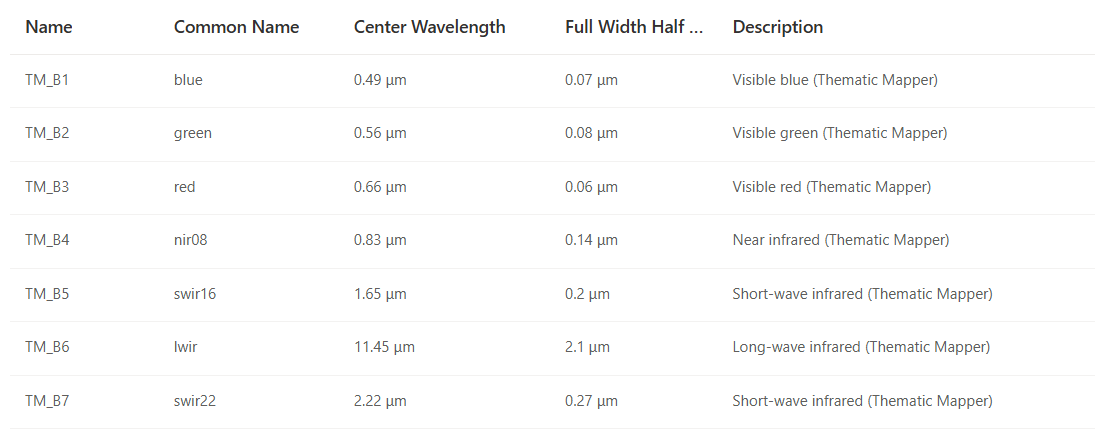

In [13]:
# B10 is the thermal infrared /surface temperture band
green_june_fn = os.path.join(imgdir, june_id+'_SR_B2.TIF')
swir_june_fn = os.path.join(imgdir, june_id+'_SR_B5.TIF')

green_early_july_fn = os.path.join(imgdir, early_july_id+'_SR_B2.TIF')
swir_early_july_fn = os.path.join(imgdir, early_july_id+'_SR_B5.TIF')

green_mid_july_fn = os.path.join(imgdir, mid_july_id+'_SR_B2.TIF')
swir_mid_july_fn = os.path.join(imgdir, mid_july_id+'_SR_B5.TIF')

green_july_august_fn = os.path.join(imgdir, july_august_id+'_SR_B2.TIF')
swir_july_august_fn = os.path.join(imgdir, july_august_id+'_SR_B5.TIF')

green_early_august_fn = os.path.join(imgdir, early_august_id+'_SR_B2.TIF')
swir_early_august_fn = os.path.join(imgdir, early_august_id+'_SR_B5.TIF')

green_late_august_fn = os.path.join(imgdir, late_august_id+'_SR_B2.TIF')
swir_late_august_fn = os.path.join(imgdir, late_august_id+'_SR_B5.TIF')

In [16]:
#!gdalinfo $imgdir/$june_id'_SR_B2.TIF';   #UTM Zone 10N

In [29]:
green_june_da = rxr.open_rasterio(green_june_fn,masked=True).squeeze()
#green_june_da

swir_june_da = rxr.open_rasterio(swir_june_fn,masked=True).squeeze()

In [32]:
#green_june_da = None
#swir_june_da = None

In [33]:
ndsi_june_da = (green_june_da-swir_june_da)/(green_june_da + swir_june_da)

Text(0.5, 1.0, 'LANDSAT 8 NDSI')

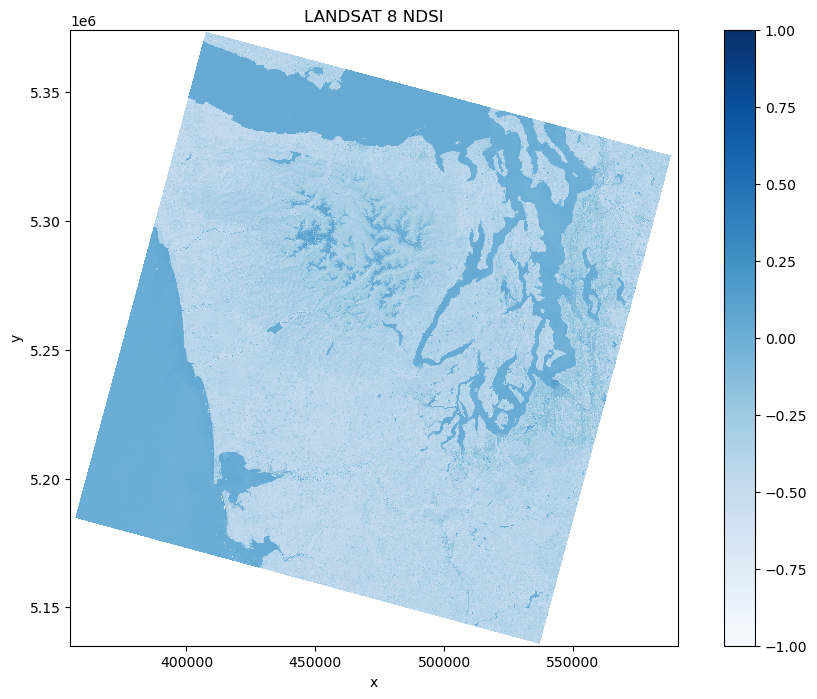

In [34]:
f,axes=plt.subplots(figsize=(12,8))

ndsi_june_da.plot.imshow(ax=axes,cmap='Blues',vmin=-1,vmax=1, robust=True)
axes.set_aspect('equal')
#axes.ticklabel_format(axis='both', style='sci', scilimits=(4,4))
axes.set_title('LANDSAT 8 NDSI')

### Need to check that bands have masked out no data values properly since colored. Also need to find better zoom in bounds for OlympicNP itself